Il compito originale richiedeva l'implementazione di algoritmi di apprendimento rinforzato nell'ambiente gym-idsgame, che modella uno scenario di rilevamento delle intrusioni nella sicurezza informatica.

Tuttavia, il pacchetto presenta attualmente problemi di compatibilità con le versioni moderne di Python e Gymnasium.  
Per garantire la riproducibilità, l'ambiente viene installato con una configurazione minima delle dipendenze e racchiuso in modo da esporre un'interfaccia a agente singolo che controlla solo il difensore.

In questo progetto:

- l'aggressore segue una politica fissa definita dall'ambiente
- l'agente di apprendimento controlla il difensore
- il wrapper converte l'ambiente multi-agente in un'interfaccia RL standard.

Questo ci permette di applicare SARSA e DDQN mantenendo l'interpretazione di sicurezza informatica del compito.

In [1]:
!pip install gym==0.25.2
!pip install scikit-learn
!pip install torch
!pip install --no-deps gym-idsgame

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.8/452.8 kB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gym-idsgame: filename=gym_idsgame-1.0.13-py3-none-any.whl size=969599 sha256=2256ada4472e991ab0e66d9d72549be86560324f13c97cf9f6913eb4aa9f928a
  Stored in directory: /root/.cache/pip/wheels/bb/cd/79/f439cc0b004b731a95ba5d840771ebca2bc9f8c958fcb91463
Successfully built gym-idsgame


In [1]:
import gym
import gym_idsgame
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from gym_idsgame.envs import IdsGameRandomAttackV0Env
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

Instanziamo l'ambiente

In [2]:
env = gym.make("idsgame-random_attack-v0")

print("Attacker action space:", env.attacker_action_space)
print("Defender action space:", env.defender_action_space)

/usr/local/lib/python3.12/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment idsgame-random_attack-v0 is out of date. You should consider upgrading to version `v21`.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AssertionError: The environment must specify an action space. https://www.gymlibrary.ml/content/environment_creation/

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


L’ambiente gym-idsgame è progettato come ambiente multi-agente con due attori: attacker e defender

Tuttavia gli algoritmi implementati in questo progetto (SARSA e DDQN) assumono un singolo agente.  
Per questo motivo è stato implementato un wrapper che trasforma l’ambiente in un problema single-agent in cui:

- l’agente RL controlla il defender
- l’attacker segue una policy random
- l’ambiente restituisce solo osservazione e reward del defender

In [2]:
class DefenderWrapper:

    def __init__(self, env):
        self.env = env

        # esponiamo solo lo spazio azioni del defender
        self.action_space = env.defender_action_space

        # osservazione del defender
        self.observation_space = env.observation_space

    def reset(self):

        obs = self.env.reset()

        # env restituisce (attacker_obs, defender_obs)
        if isinstance(obs, tuple):
            obs = obs[1]

        # supponendo che l'osservazione del difensore sia la prima riga di un array (3,11)
        if isinstance(obs, np.ndarray) and obs.shape == (3, 11):
            obs = obs[0:1, :] # Take the first row as (1,11) array

        return obs

    def step(self, action):

        # attacker agisce random
        attacker_action = self.env.attacker_action_space.sample()

        obs, reward, done, info = self.env.step((attacker_action, action))

        # osservazione defender
        if isinstance(obs, tuple):
            obs = obs[1]

        # supponendo che l'osservazione del difensore sia la prima riga di un array (3,11)
        if isinstance(obs, np.ndarray) and obs.shape == (3, 11):
            obs = obs[0:1, :] # Take the first row as (1,11) array

        # reward defender
        if isinstance(reward, tuple):
            reward = reward[1]

        return obs, reward, done, info

In [3]:
base_env = IdsGameRandomAttackV0Env()

env = DefenderWrapper(base_env)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

Action space: Discrete(33)
Observation space: Box(0, 9, (1, 11), int32)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Lo stato che l’agente riceve è un vettore di 11 numeri compresi tra 0 e 9.

Quindi uno stato è qualcosa tipo: [3,1,0,5,4,2,0,1,6,2,0]

Ogni numero rappresenta feature della rete difesa/attacco (livelli di difesa, vulnerabilità, detection ecc.).

In [4]:
#Test di verifica
obs = env.reset()

done = False
total_reward = 0
steps = 0

while not done:

    action = env.action_space.sample()

    obs, reward, done, info = env.step(action)

    total_reward += reward
    steps += 1

print("Steps:", steps)
print("Reward episodio:", total_reward)

Steps: 2
Reward episodio: 1


Prepariamo lo stato in modo che:

*   flatten da (3,11) a (33,)
*   normalizzazione, che facilita il learning


In [5]:
def preprocess_state(state):

    state = np.array(state)

    # uso tutte le osservazioni (3x11 -> 33)
    state = state.flatten()

    return state

SARSA

In [12]:
num_features = 11
num_actions = env.action_space.n

weights = np.zeros((num_actions, num_features)) #inizializzazione pesi. Questa matrice rappresenta: Q(s,a) = weights[a] · s

In [13]:
def q_value(state, action):#creiamo una funzione che calcola il valore Q
    action = int(action)
    return np.dot(weights[action], state)

In [14]:
def select_action(state, epsilon):#policy epsilon-greedy

    if np.random.rand() < epsilon:
        return np.random.randint(num_actions)

    q_values = [q_value(state, a) for a in range(num_actions)]
    return np.argmax(q_values)

In [15]:
print("weights shape:", weights.shape)

s = preprocess_state(env.reset())
a = select_action(s, 0.1)

print("state shape:", s.shape)
print("action:", a)
print("weights[action] shape:", weights[a].shape)

weights shape: (33, 11)
state shape: (11,)
action: 0
weights[action] shape: (11,)


Training SARSA

In [16]:
alpha = 0.01
gamma = 0.99
epsilon = 0.1

num_episodes = 2000

episode_rewards = []

for episode in range(num_episodes):

    state = env.reset()
    state = preprocess_state(state)

    action = select_action(state, epsilon)

    done = False
    total_reward = 0

    while not done:

        next_state, reward, done, _ = env.step(action)

        next_state = preprocess_state(next_state)

        next_action = select_action(next_state, epsilon)

        q_current = q_value(state, action)
        q_next = q_value(next_state, next_action)

        td_target = reward + gamma * q_next
        td_error = td_target - q_current

        weights[action] += alpha * td_error * state

        state = next_state
        action = next_action

        total_reward += reward

    episode_rewards.append(total_reward)

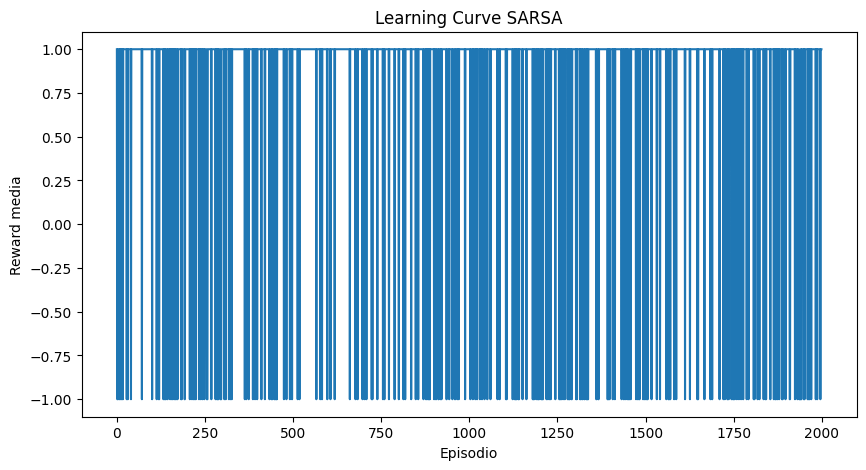

In [17]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards)

plt.title("Learning Curve SARSA")
plt.xlabel("Episodio")
plt.ylabel("Reward media")

plt.show()

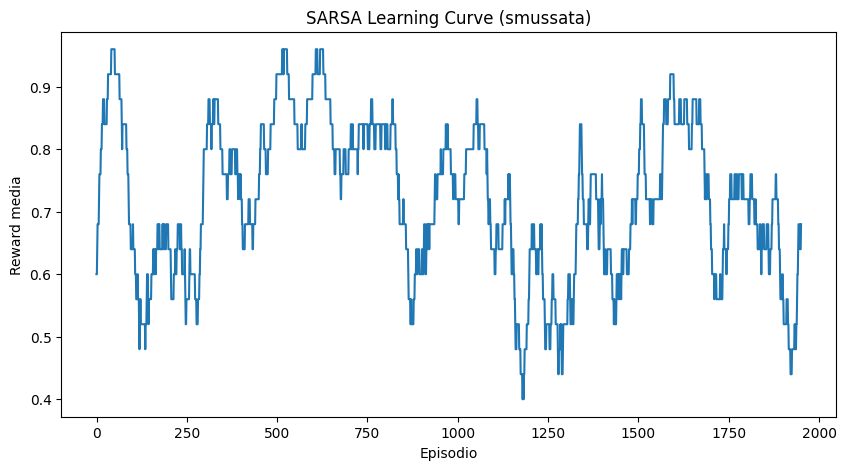

In [18]:
window = 50

smoothed_rewards = np.convolve(episode_rewards,np.ones(window)/window,mode="valid")

plt.figure(figsize=(10,5))

plt.plot(smoothed_rewards)

plt.title("SARSA Learning Curve (smussata)")
plt.xlabel("Episodio")
plt.ylabel("Reward media")

plt.show()

La curva di apprendimento mostra che il defender migliora rispetto a una strategia casuale. La media mobile del reward si stabilizza tra 0.6 e 0.7, indicando che l’agente riesce a bloccare l’attacco nella maggioranza degli episodi. Le oscillazioni sono dovute alla componente stocastica dell’ambiente e alla policy epsilon-greedy utilizzata durante l’addestramento.

Double DQN

In [19]:
class QNetwork(nn.Module): #definiamo la rete neurale

    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

Scenario Maximal Attack per DDQN

In [20]:
from gym_idsgame.envs import IdsGameMaximalAttackV0Env

base_env_ddqn = IdsGameMaximalAttackV0Env()
env_ddqn = DefenderWrapper(base_env_ddqn)

Creiamo policy network e target network

In [27]:
state_dim = 11
action_dim = env_ddqn.action_space.n

policy_net = QNetwork(state_dim, action_dim)
target_net = QNetwork(state_dim, action_dim)

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)

In [28]:
def select_action_dqn(state, epsilon): #epsilon greedy per DQN

    if np.random.rand() < epsilon:
        return env.action_space.sample()

    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state_tensor)

    return int(torch.argmax(q_values))

In [29]:
replay_buffer = deque(maxlen=10000) # Il replay buffer salva le esperienze (s, a, r, s', done)

def store_transition(state, action, reward, next_state, done):
    replay_buffer.append((state, action, reward, next_state, done))

Funzione di training DDQN

In [30]:
batch_size = 64
gamma = 0.99

def train_step():

    if len(replay_buffer) < batch_size:
        return

    batch = random.sample(replay_buffer, batch_size)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(dones)

    # Q(s,a)
    q_values = policy_net(states).gather(1, actions).squeeze()

    # Double DQN
    next_actions = torch.argmax(policy_net(next_states), dim=1)

    next_q_values = target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze()

    targets = rewards + gamma * next_q_values * (1 - dones)

    loss = nn.MSELoss()(q_values, targets.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

policy_net sceglie l’azione migliore, target_net valuta quell’azione

Training loop DDQN

In [31]:
num_episodes = 2000

epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

target_update = 50

episode_rewards_dqn = []

for episode in range(num_episodes):

    state = preprocess_state(env_ddqn.reset())
    done = False
    total_reward = 0

    while not done:

        action = select_action_dqn(state, epsilon)

        next_state, reward, done, _ = env_ddqn.step(action)

        next_state = preprocess_state(next_state)

        store_transition(state, action, reward, next_state, done)

        train_step()

        state = next_state
        total_reward += reward

    episode_rewards_dqn.append(total_reward)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if episode % 100 == 0:
        print("Episode:", episode, "Reward:", total_reward)

Episode: 0 Reward: 1
Episode: 100 Reward: 1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Episode: 200 Reward: -1
Episode: 300 Reward: -1
Episode: 400 Reward: 1
Episode: 500 Reward: 1
Episode: 600 Reward: -1
Episode: 700 Reward: 1
Episode: 800 Reward: 1
Episode: 900 Reward: 1
Episode: 1000 Reward: 1
Episode: 1100 Reward: -1
Episode: 1200 Reward: -1
Episode: 1300 Reward: 1
Episode: 1400 Reward: 1
Episode: 1500 Reward: 1
Episode: 1600 Reward: 1
Episode: 1700 Reward: 1
Episode: 1800 Reward: 1
Episode: 1900 Reward: 1


Valutazione della policy senza esplorazione

In [32]:
def evaluate_policy(env, episodes=100):

    rewards = []

    for ep in range(episodes):

        state = preprocess_state(env.reset())
        done = False
        total_reward = 0

        while not done:

            action = select_action_dqn(state, epsilon=0.0)

            next_state, reward, done, _ = env.step(action)
            next_state = preprocess_state(next_state)

            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    print("Evaluation mean reward:", np.mean(rewards))
    return rewards

In [33]:
evaluation_rewards = evaluate_policy(env_ddqn, episodes=100)

Evaluation mean reward: 0.8


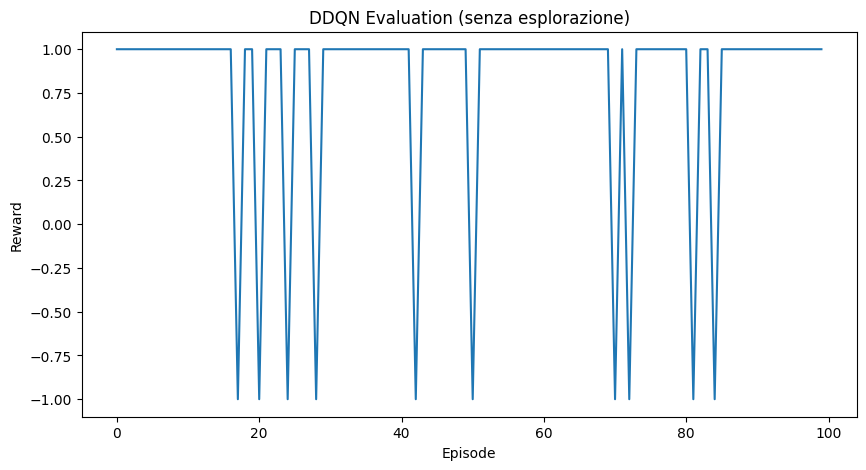

In [35]:
plt.figure(figsize=(10,5))
plt.plot(evaluation_rewards)

plt.title("DDQN Evaluation (senza esplorazione)")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.show()

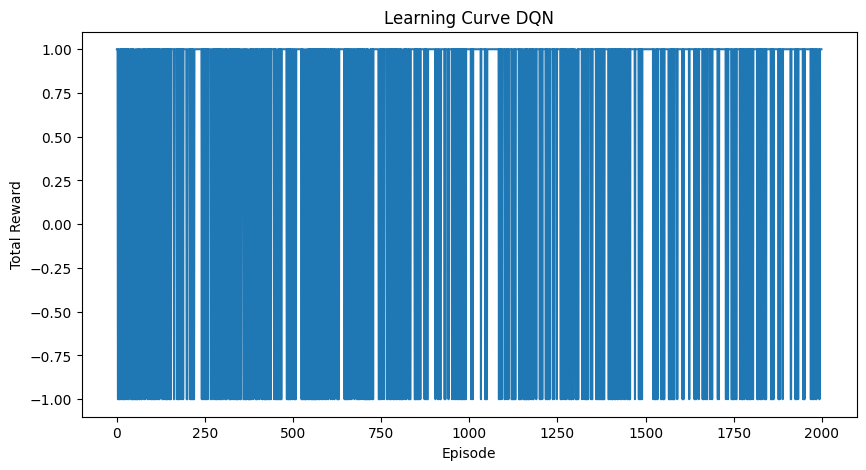

In [36]:
plt.figure(figsize=(10,5))

plt.plot(episode_rewards_dqn)

plt.title("Learning Curve DQN")
plt.xlabel("Episode")
plt.ylabel("Total Reward")

plt.show()

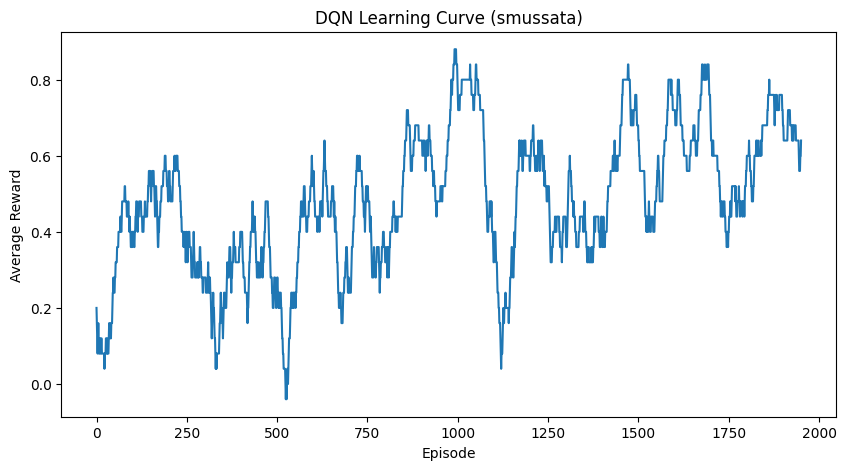

In [37]:
window = 50

smoothed_dqn = np.convolve(episode_rewards_dqn, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))

plt.plot(smoothed_dqn)

plt.title("DQN Learning Curve (smussata)")
plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.show()

Confronto SARA-DQN

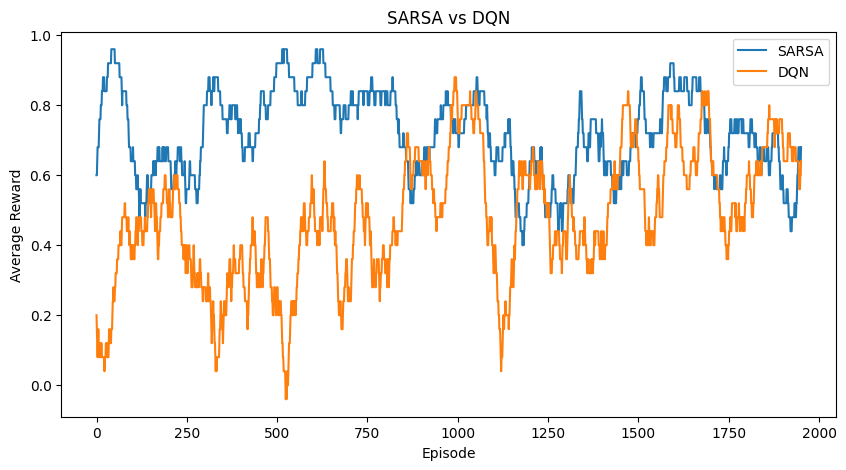

In [38]:
window = 50

sarsa_smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

dqn_smooth = np.convolve(episode_rewards_dqn, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))

plt.plot(sarsa_smooth, label="SARSA")
plt.plot(dqn_smooth, label="DQN")

plt.title("SARSA vs DQN")
plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.legend()

plt.show()

SARSA è un algoritmo on-policy che aggiorna i valori Q utilizzando l’azione effettivamente scelta dalla policy corrente. Questo rende l’apprendimento più conservativo ma anche più stabile, perché l’agente impara direttamente dal comportamento che sta eseguendo. Nel nostro caso SARSA riesce progressivamente a migliorare la strategia del difensore osservando le ricompense ottenute negli episodi.

Tuttavia SARSA utilizza una rappresentazione lineare della funzione Q e quindi ha capacità limitata quando lo spazio degli stati diventa complesso. Per questo motivo abbiamo implementato anche Deep Q-Learning, dove la funzione Q viene approssimata da una rete neurale.

Nel caso di Double DQN vengono utilizzate due reti:

*   policy network, che seleziona l’azione migliore
*   target network, che valuta il valore di quell’azione

Questa separazione riduce il problema della sovrastima dei Q-values, rendendo l’allenamento più stabile. Inoltre l’uso del replay buffer permette di campionare esperienze passate in modo casuale, rompendo la correlazione temporale tra le osservazioni e migliorando l’efficienza dell’apprendimento.

Dalle learning curves si osserva che l’agente migliora progressivamente le proprie performance, indicando che l’algoritmo sta effettivamente imparando una politica migliore nel tempo.